### Check shape

In [ ]:
import numpy as np

data = np.load('eski/output3/panoptic/multi_person_posenet_50/knn5-lr4-q1024/exp-20251217-204719-0.1.npy')
print(f"Shape: {data.shape}")
print(f"First joint of first frame: {data[0,0]}")

### Check confidences

In [16]:
import numpy as np

# 1. Load your data
file_path = 'output/panoptic/multi_person_posenet_50/emre_config/gokcanmarker1.npy'
data = np.load(file_path)

# 2. Define output text file name
output_txt = 'confidence_results.txt'

print(f"Processing {data.shape[0]} frames...")

# 3. Open the file in 'write' mode ('w')
with open(output_txt, 'w') as f:
    # Write a header
    f.write(f"Analysis of: {file_path}\n")
    f.write(f"Total Frames: {data.shape[0]}\n")
    f.write("-" * 50 + "\n")

    # Loop through every frame
    for frame_idx in range(data.shape[0]):
        # Get candidates for this frame
        candidates = data[frame_idx]
        
        # Calculate scores (average of column 4 across all joints)
        person_scores = np.mean(candidates[:, :, 4], axis=1) 
        
        # Find the best candidate
        best_idx = np.argmax(person_scores)
        max_score = person_scores[best_idx]
        
        # Create the string line
        line = f"Frame {frame_idx:03d}: Max Score = {max_score:.6f} (Candidate Index: {best_idx})\n"
        
        # Write to file
        f.write(line)

print(f"Success! The full list is saved in '{output_txt}'.")

Processing 209 frames...
Success! The full list is saved in 'confidence_results.txt'.


### Drawing skeletons in 3D space

--- FRAME 150 DEBUG ---
Selected Candidate Index: 0
Confidence Score: 0.0002

Coordinate Sample (First 5 joints):
[[ -359.7557  -1194.9149   2570.9421 ]
 [ -307.96878 -1239.6346   2583.277  ]
 [ 1014.70276  1055.0092   2660.781  ]
 [ -292.95465 -1240.108    2607.5095 ]
 [-1140.8075   -725.5322   2370.8408 ]]

Range X: -1140.81 to 1354.94
Range Y: -1240.11 to 1326.08
Range Z: 2370.84 to 2704.50


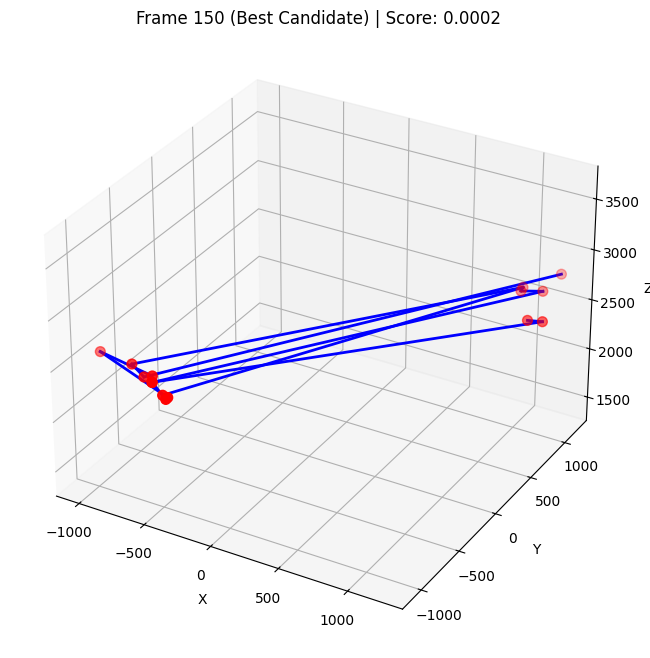

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ================= CONFIGURATION =================
FILE_PATH = 'output/panoptic/multi_person_posenet_50/emre_config/sinamarker1.npy'
FRAME_IDX = 150  # The frame with the highest score (0.466)

# Standard 15-Joint Connectivity
SKELETON_BONES = [
    (0, 1),   # Neck -> Nose
    (0, 2),   # Neck -> Pelvis (Spine)
    (0, 3), (3, 4), (4, 5),      # Left Arm
    (0, 9), (9, 10), (10, 11),   # Right Arm
    (2, 6), (6, 7), (7, 8),      # Left Leg
    (2, 12), (12, 13), (13, 14)  # Right Leg
]
# =================================================

def debug_frame_11():
    # 1. Load Data
    data = np.load(FILE_PATH) # Shape (31, 1024, 15, 5)
    
    # 2. Get all 1024 candidates for Frame 11
    candidates = data[FRAME_IDX] # Shape (1024, 15, 5)
    
    # 3. Find the best candidate
    # Average the confidence (index 4) across all 15 joints
    scores = np.mean(candidates[:, :, 4], axis=1)
    best_idx = np.argmax(scores)
    best_pose = candidates[best_idx] # Shape (15, 5)
    best_score = scores[best_idx]
    
    # Extract coordinates (X, Y, Z)
    xs = best_pose[:, 0]
    ys = best_pose[:, 1]
    zs = best_pose[:, 2]

    # --- DEBUG PRINT ---
    print(f"--- FRAME {FRAME_IDX} DEBUG ---")
    print(f"Selected Candidate Index: {best_idx}")
    print(f"Confidence Score: {best_score:.4f}")
    print("\nCoordinate Sample (First 5 joints):")
    print(best_pose[:5, :3]) # Print X,Y,Z of first 5 joints
    
    # Check bounds to determine units
    print(f"\nRange X: {xs.min():.2f} to {xs.max():.2f}")
    print(f"Range Y: {ys.min():.2f} to {ys.max():.2f}")
    print(f"Range Z: {zs.min():.2f} to {zs.max():.2f}")
    
    if np.all(xs == 0) and np.all(ys == 0):
        print("\nCRITICAL WARNING: All coordinates are ZERO. The model did not output valid positions.")
        return

    # 4. Plot with Auto-Scaling
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot Joints
    ax.scatter(xs, ys, zs, c='r', s=50, label='Joints')
    
    # Plot Bones
    for start, end in SKELETON_BONES:
        ax.plot([xs[start], xs[end]], [ys[start], ys[end]], [zs[start], zs[end]], 'b-', linewidth=2)

    # --- CRITICAL: AUTO-CENTER THE CAMERA ---
    # We find the center of the data and create a box around it
    mid_x = (xs.max() + xs.min()) * 0.5
    mid_y = (ys.max() + ys.min()) * 0.5
    mid_z = (zs.max() + zs.min()) * 0.5
    
    # Determine the "span" (how wide the skeleton is)
    max_range = np.array([xs.max()-xs.min(), ys.max()-ys.min(), zs.max()-zs.min()]).max() / 2.0
    
    # Add a small buffer if range is 0 (single point)
    if max_range == 0: max_range = 1.0
    
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f"Frame {FRAME_IDX} (Best Candidate) | Score: {best_score:.4f}")
    
    plt.show()

if __name__ == "__main__":
    debug_frame_11()

### With rotation of the space

In [5]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "browser"

# ================= CONFIGURATION =================
FILE_PATH = 'output/panoptic/multi_person_posenet_50/emre_config/sinamarker1.npy'
FRAME_TO_VIEW = 150  # The frame you saw had good data

# CMU Panoptic 15-Joint Connections
# Format: (Start_Index, End_Index)
BONES = [
    (0, 1), (0, 2),             # Neck->Nose, Neck->MidHip
    (0, 3), (3, 4), (4, 5),     # Left Arm
    (0, 9), (9, 10), (10, 11),  # Right Arm
    (2, 6), (6, 7), (7, 8),     # Left Leg
    (2, 12), (12, 13), (13, 14) # Right Leg
]

# Joint Names for Hover Info
JOINT_NAMES = [
    "Neck", "Nose", "Mid-Hip",
    "L-Sho", "L-Elb", "L-Wri",
    "L-Hip", "L-Knee", "L-Ank",
    "R-Sho", "R-Elb", "R-Wri",
    "R-Hip", "R-Knee", "R-Ank"
]
# =================================================

def plot_interactive_frame(frame_idx):
    # 1. Load Data
    data = np.load(FILE_PATH) # (31, 1024, 15, 5)
    
    # 2. Get Best Person in this Frame
    candidates = data[frame_idx]
    scores = np.mean(candidates[:, :, 4], axis=1)
    best_idx = np.argmax(scores)
    
    pose = candidates[best_idx]     # Shape (15, 5)
    score = scores[best_idx]
    
    xs = pose[:, 0]
    ys = pose[:, 1]
    zs = pose[:, 2]
    
    # 3. Create Plotly Figure
    fig = go.Figure()

    # Add Joints (Dots)
    fig.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode='markers',
        marker=dict(size=5, color='red'),
        name='Joints',
        text=JOINT_NAMES, # Show joint name on hover
        hoverinfo='text'
    ))

    # Add Bones (Lines)
    # Plotly draws lines by connecting lists of points. 
    # We add a generic "trace" for all bones or one per bone.
    x_lines, y_lines, z_lines = [], [], []
    for start, end in BONES:
        x_lines.extend([xs[start], xs[end], None]) # None breaks the line segment
        y_lines.extend([ys[start], ys[end], None])
        z_lines.extend([zs[start], zs[end], None])

    fig.add_trace(go.Scatter3d(
        x=x_lines, y=y_lines, z=z_lines,
        mode='lines',
        line=dict(color='blue', width=4),
        name='Skeleton'
    ))

    # 4. Update Layout for correct 3D Aspect Ratio
    fig.update_layout(
        title=f"Frame {frame_idx} | Confidence: {score:.4f}",
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data' # CRITICAL: Keeps skeleton proportions real
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

# Run the function
plot_interactive_frame(FRAME_TO_VIEW)

KeyboardInterrupt: 

Frame 91: Drawn 1 skeletons.


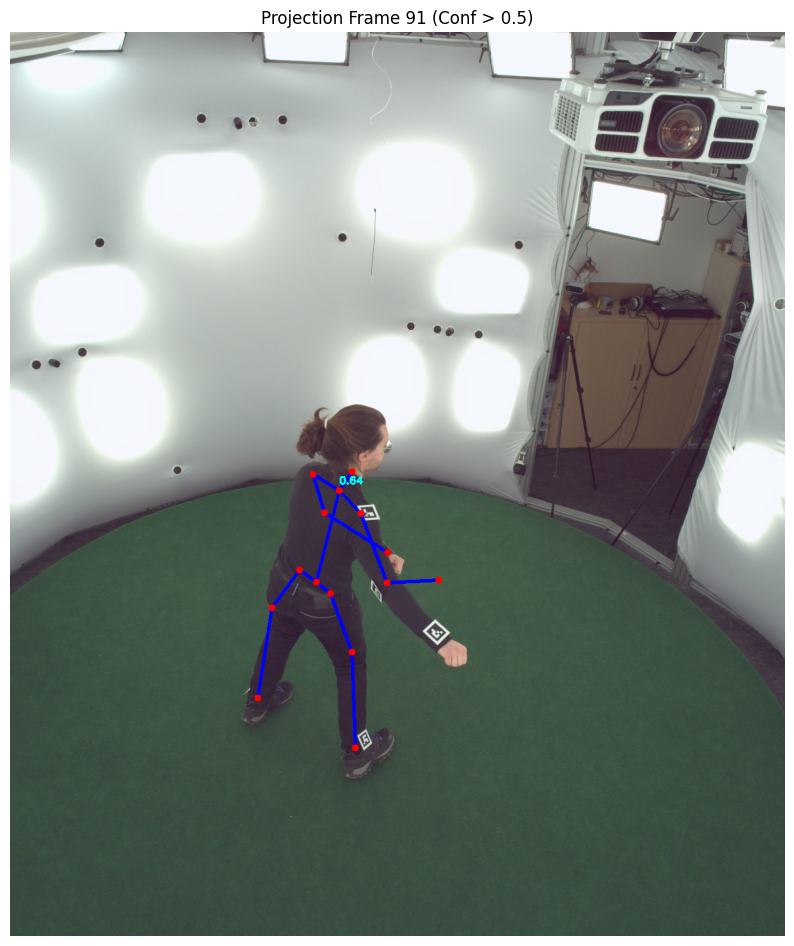

In [17]:
import numpy as np
import cv2
import json
import os
import matplotlib.pyplot as plt

# ================= CONFIGURATION =================
# 1. Paths
NPY_PATH = 'output/panoptic/multi_person_posenet_50/emre_config/gokcanmarker1.npy'
# Make sure to point to the RESIZED image (1152x1344)
IMG_PATH = 'data/emre_dataset/my_seq_1motionGokcan/hdImgs/00_31/00_31_00000091.jpg' 
CALIB_PATH = 'data/emre_dataset/my_seq_1motionEmre/calibration_my_seq_1.json'

# 2. Settings
FRAME_IDX = 91          # Frame to visualize
CONFIDENCE_THR = 0.5 # Only draw skeletons with score >
CAM_NAME = "00_31"       # Camera name in JSON

# 3. Skeleton Topology (Panoptic 15-Joints)
BONES = [
    (0, 1), (0, 2),             # Neck->Nose, Neck->MidHip
    (0, 3), (3, 4), (4, 5),     # Left Arm
    (0, 9), (9, 10), (10, 11),  # Right Arm
    (2, 6), (6, 7), (7, 8),     # Left Leg
    (2, 12), (12, 13), (13, 14) # Right Leg
]
# Colors (B, G, R)
COLOR_BONE = (255, 0, 0)   # Blue
COLOR_JOINT = (0, 0, 255)  # Red
# =================================================

def project_3d_to_2d(pose_3d, K, R, t):
    """
    Projects 3D points (MM) to 2D pixels using Camera Matrices.
    P_pixel = K * (R * P_world + t)
    """
    # 1. Transform World -> Camera
    # pose_3d shape: (15, 3) -> Transpose to (3, 15)
    points_world = pose_3d.T 
    
    # P_cam = R * P_world + t
    # t is (3, 1), points_world is (3, 15) -> Broadcasting works
    points_cam = np.dot(R, points_world) + t 
    
    # 2. Project Camera -> Pixel (Homogeneous)
    points_2d_homo = np.dot(K, points_cam) # Shape (3, 15)
    
    # 3. Normalize (u = x/z, v = y/z)
    # Avoid division by zero
    z = points_2d_homo[2, :]
    z[z == 0] = 1e-5 
    
    u = points_2d_homo[0, :] / z
    v = points_2d_homo[1, :] / z
    
    return np.stack([u, v], axis=1) # Shape (15, 2)

def main():
    # --- 1. Load Data ---
    # Load Image
    if not os.path.exists(IMG_PATH):
        print(f"Error: Image not found {IMG_PATH}")
        return
    img = cv2.imread(IMG_PATH)
    h, w = img.shape[:2]
    
    # Load Calibration
    with open(CALIB_PATH) as f:
        full_json = json.load(f)
    cam_data = next((c for c in full_json["cameras"] if c["name"] == CAM_NAME), full_json["cameras"][0])

    # Load 3D Poses
    all_preds = np.load(NPY_PATH) # (Frames, Candidates, 15, 5)
    frame_preds = all_preds[FRAME_IDX]
    
    # --- 2. Setup Matrices (Match panoptic.py logic) ---
    
    # A. Rotation M (The one we fixed: Y-Up to Z-Up/Down)
    # Must match EXACTLY what is in your panoptic.py
    M = np.array([[1.0, 0.0, 0.0],
                  [0.0, 0.0, 1.0],
                  [0.0, -1.0, 0.0]])

    # B. Extrinsics
    R_raw = np.array(cam_data['R'])
    t_raw = np.array(cam_data['t']).reshape(3, 1) # CM
    
    # Apply Transformations
    # 1. Rotate R to match Model Space
    R_proj = R_raw.dot(M)
    
    # 2. Scale t to MM (Model Space uses MM)
    t_proj = t_raw * 10.0 
    
    # C. Intrinsics
    K = np.array(cam_data['K'])
    # Note: If you resized your image to 1152x1344, 
    # and your JSON is 1152x1344, we do NOT scale K.
    
    # --- 3. Draw Skeletons ---
    drawn_count = 0
    
    for candidate in frame_preds:
        # candidate shape: (15, 5) -> [x, y, z, score, score_avg]
        # Calculate score (avg of col 4)
        score = np.mean(candidate[:, 4])
        
        if score < CONFIDENCE_THR:
            continue
            
        pose_3d_mm = candidate[:, 0:3] # XYZ in MM
        
        # Project
        pose_2d = project_3d_to_2d(pose_3d_mm, K, R_proj, t_proj)
        
        # Check if points are in bounds (simple check)
        if np.any(pose_2d < -500) or np.any(pose_2d > w + 500):
            continue

        drawn_count += 1
        
        # Draw Bones
        for start, end in BONES:
            pt1 = tuple(pose_2d[start].astype(int))
            pt2 = tuple(pose_2d[end].astype(int))
            cv2.line(img, pt1, pt2, COLOR_BONE, 3)
            
        # Draw Joints
        for i in range(len(pose_2d)):
            pt = tuple(pose_2d[i].astype(int))
            cv2.circle(img, pt, 5, COLOR_JOINT, -1)
            
        # Draw Score Label
        head_pt = tuple(pose_2d[0].astype(int)) # Neck
        cv2.putText(img, f"{score:.2f}", (head_pt[0], head_pt[1]-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)

    # --- 4. Show Result ---
    print(f"Frame {FRAME_IDX}: Drawn {drawn_count} skeletons.")
    
    # Convert BGR to RGB for Matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 12))
    plt.imshow(img_rgb)
    plt.title(f"Projection Frame {FRAME_IDX} (Conf > {CONFIDENCE_THR})")
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    main()

In [9]:
import numpy as np
import json
import plotly.graph_objects as go

# ================= CONFIGURATION =================
GT_JSON_PATH = '/data/home/student_colak/MVGFormer/ArUco_VCI_Skeleton/detections_motion_sina.json'
NPY_PATH = 'output/panoptic/multi_person_posenet_50/emre_config/sinamarker1.npy'

# The clean, un-crossed mapping
GT_TO_PRED_MAP = {
    2:  3,  # L-Shoulder 
    5:  9,  # R-Shoulder 
    1:  4,  # L-Elbow 
    4:  10, # R-Elbow 
    3:  11,  # L-Wrist 
    0:  5, # R-Wrist 
    7:  7,  # L-Knee 
    9:  13, # R-Knee 
    6:  8,  # L-Ankle
    8:  14  # R-Ankle
}

PANOPTIC_NAMES = {
    3: 'L-Shoulder', 4: 'L-Elbow', 5: 'L-Wrist', 
    7: 'L-Knee', 8: 'L-Ankle', 9: 'R-Shoulder', 10: 'R-Elbow', 
    11: 'R-Wrist', 13: 'R-Knee', 14: 'R-Ankle'
}
# =================================================

def align_procrustes_with_scale(X, Y):
    muX = X.mean(0)
    muY = Y.mean(0)
    X0 = X - muX
    Y0 = Y - muY
    scale = np.sqrt(np.sum(Y0**2) / np.sum(X0**2))
    X0_scaled = X0 * scale
    H = np.dot(X0_scaled.T, Y0)
    U, S, Vt = np.linalg.svd(H)
    
    # --- THE BUG FIX IS HERE ---
    # Because X and Y are (N, 3) row vectors, the correct rotation is U @ Vt.
    # The previous code (Vt.T @ U.T) was applying the inverse rotation!
    R = np.dot(U, Vt) 
    
    if np.linalg.det(R) < 0:
        print("⚠️ Mirrored ArUco Coordinate System Detected! Safely flipping...")
        
    t = muY - np.dot(muX * scale, R)
    aligned_X = np.dot(X * scale, R) + t
    return aligned_X, scale

def main():
    with open(GT_JSON_PATH, 'r') as f:
        gt_data = json.load(f)
        
    all_preds = np.load(NPY_PATH)

    for frame_str, gt_joints_dict in gt_data.items():
        frame_idx = int(frame_str)
        
        if frame_idx >= len(all_preds) or len(all_preds[frame_idx]) == 0:
            continue
            
        gt_points_mm = np.zeros((12, 3))
        for j_idx in range(12):
            if str(j_idx) in gt_joints_dict:
                gt_points_mm[j_idx] = np.array(gt_joints_dict[str(j_idx)]) * 1000.0
            else:
                gt_points_mm[j_idx] = [np.nan, np.nan, np.nan]
                
        frame_preds = all_preds[frame_idx]
        scores = [np.mean(candidate[:, 4]) for candidate in frame_preds]
        best_candidate = frame_preds[np.argmax(scores)]
        pred_points_mm = best_candidate[:, 0:3] 
        
        matched_gt = []
        matched_pred = []
        labels_gt = []
        labels_pred = []
        
        for gt_idx, pred_idx in GT_TO_PRED_MAP.items():
            gt_pt = gt_points_mm[gt_idx]
            if not np.isnan(gt_pt).any():
                matched_gt.append(gt_pt)
                matched_pred.append(pred_points_mm[pred_idx])
                labels_gt.append(f"ArUco {gt_idx} ({PANOPTIC_NAMES[pred_idx]})")
                labels_pred.append(f"Pred {PANOPTIC_NAMES[pred_idx]}")
                
        matched_gt = np.array(matched_gt)
        matched_pred = np.array(matched_pred)
        
        if len(matched_gt) < 3:
            continue
            
        aligned_pred, scale_factor = align_procrustes_with_scale(matched_pred, matched_gt)
        distances = np.linalg.norm(matched_gt - aligned_pred, axis=1)
        mean_error = np.mean(distances)

        print(f"Frame {frame_idx} - Mean Error: {mean_error:.2f} mm | Scale Applied: {scale_factor:.4f}")

        # --- PLOTLY VISUALIZATION ---
        fig = go.Figure()

        fig.add_trace(go.Scatter3d(
            x=matched_gt[:, 0], y=matched_gt[:, 1], z=matched_gt[:, 2],
            mode='markers+text',
            marker=dict(size=8, color='green', opacity=0.8),
            text=labels_gt,
            textposition="top center",
            name="Ground Truth (ArUco)"
        ))

        fig.add_trace(go.Scatter3d(
            x=aligned_pred[:, 0], y=aligned_pred[:, 1], z=aligned_pred[:, 2],
            mode='markers+text',
            marker=dict(size=6, color='red', symbol='diamond', opacity=0.8),
            text=labels_pred,
            textposition="bottom center",
            name="Aligned Prediction"
        ))

        for i in range(len(matched_gt)):
            fig.add_trace(go.Scatter3d(
                x=[matched_gt[i, 0], aligned_pred[i, 0], None],
                y=[matched_gt[i, 1], aligned_pred[i, 1], None],
                z=[matched_gt[i, 2], aligned_pred[i, 2], None],
                mode='lines',
                line=dict(color='black', width=3, dash='dash'),
                showlegend=False,
                hoverinfo='text',
                hovertext=f"Joint Error: {distances[i]:.2f} mm"
            ))

        fig.update_layout(
            title=f"Error Visualization (Frame {frame_idx}) - PA-MPJPE: {mean_error:.2f} mm",
            scene=dict(xaxis_title='X (mm)', yaxis_title='Y (mm)', zaxis_title='Z (mm)', aspectmode='data'),
            legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
        )

        fig.show()
        break 

if __name__ == "__main__":
    main()

⚠️ Mirrored ArUco Coordinate System Detected! Safely flipping...
Frame 0 - Mean Error: 73.87 mm | Scale Applied: 0.9936


KeyboardInterrupt: 

Evaluated 104 frames.
Overall Sequence PA-MPJPE: 243.08 mm


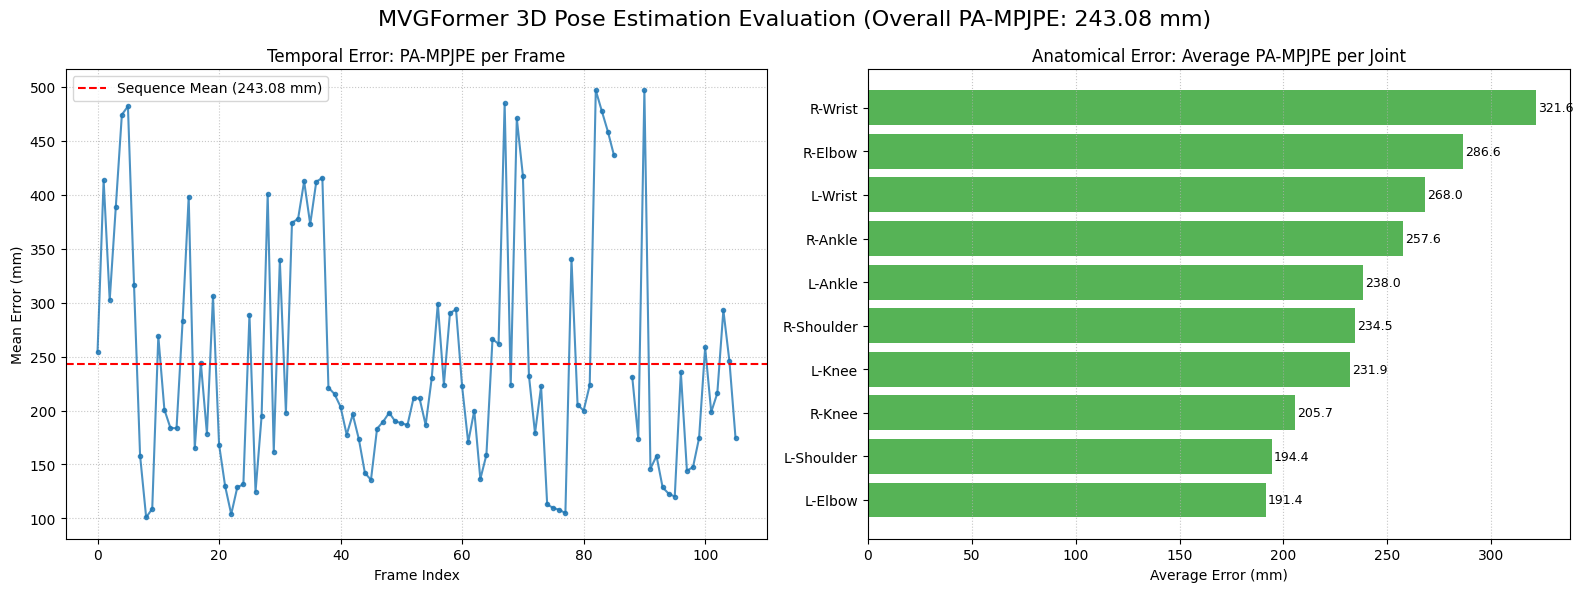

Evaluated 104 frames.
Overall Sequence PA-MPJPE: 243.08 mm


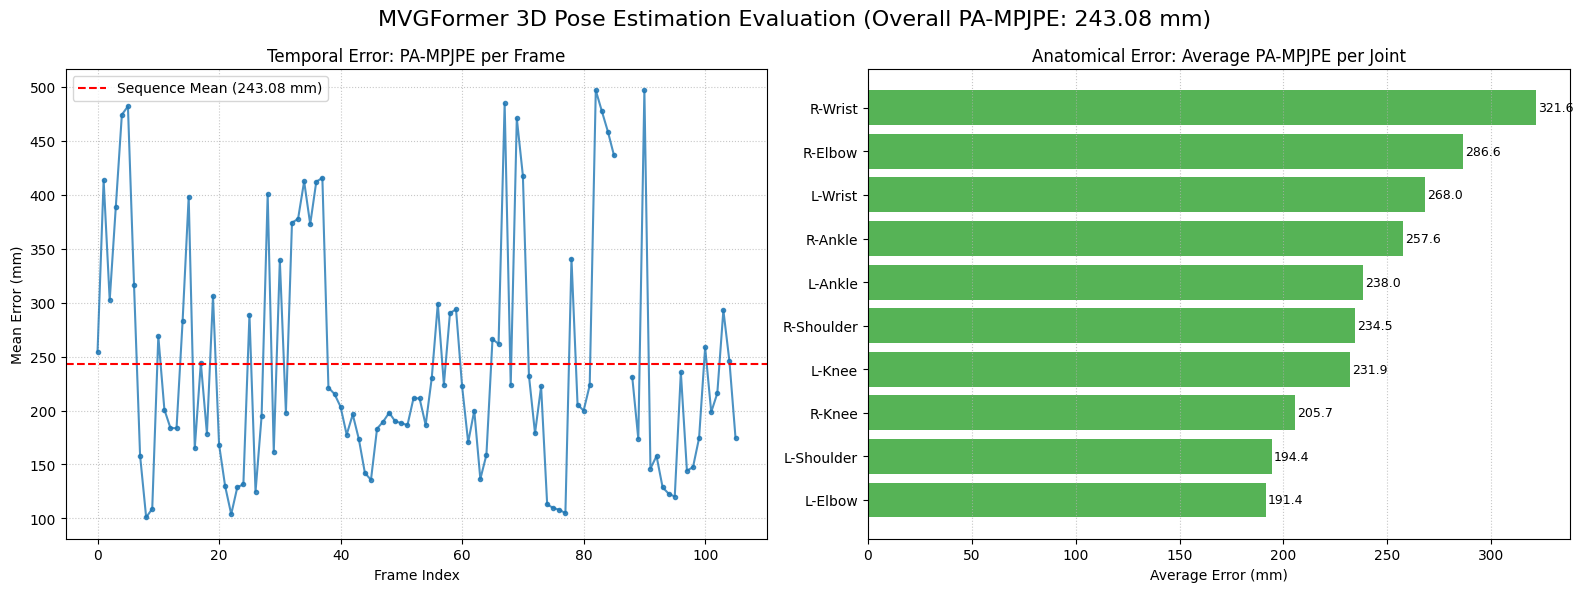

In [29]:
import numpy as np
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# ================= CONFIGURATION =================
GT_JSON_PATH = '/data/home/student_colak/MVGFormer/ArUco_VCI_Skeleton/detections_motion_markus.json'
NPY_PATH = 'output/panoptic/multi_person_posenet_50/emre_config/markusmarker3.npy'
CONFIDENCE_THRESHOLD = 0.3

# The final, correct physical mapping
GT_TO_PRED_MAP = {
    2:  3,  # L-Shoulder 
    5:  9,  # R-Shoulder 
    1:  4,  # L-Elbow 
    4:  10, # R-Elbow 
    3:  11,  # L-Wrist 
    0:  5, # R-Wrist 
    7:  7,  # L-Knee 
    9:  13, # R-Knee 
    6:  8,  # L-Ankle
    8:  14  # R-Ankle
}

PANOPTIC_NAMES = {
    3: 'L-Shoulder', 4: 'L-Elbow', 5: 'L-Wrist', 
    7: 'L-Knee', 8: 'L-Ankle', 9: 'R-Shoulder', 10: 'R-Elbow', 
    11: 'R-Wrist', 13: 'R-Knee', 14: 'R-Ankle'
}
# =================================================
def align_procrustes_with_scale(X, Y):
    muX = X.mean(0)
    muY = Y.mean(0)
    X0 = X - muX
    Y0 = Y - muY

    ssX = np.sum(X0**2)
    ssY = np.sum(Y0**2)

    # Skip degenerate cases where all points collapse to a single point
    if ssX < 1e-12 or ssY < 1e-12:
        return None

    scale = np.sqrt(ssY / ssX)
    X0_scaled = X0 * scale
    H = np.dot(X0_scaled.T, Y0)

    # Check for NaN/Inf before SVD
    if not np.all(np.isfinite(H)):
        return None

    U, S, Vt = np.linalg.svd(H)

    # The corrected rotation math
    R = np.dot(U, Vt)

    if np.linalg.det(R) < 0:
        # Silently allow reflection to handle the inverted camera space
        pass

    t = muY - np.dot(muX * scale, R)
    aligned_X = np.dot(X * scale, R) + t
    return aligned_X

def align_procrustes_with_scale2(X, Y):
    muX = X.mean(0)
    muY = Y.mean(0)
    X0 = X - muX
    Y0 = Y - muY
    scale = np.sqrt(np.sum(Y0**2) / np.sum(X0**2))
    X0_scaled = X0 * scale
    H = np.dot(X0_scaled.T, Y0)
    U, S, Vt = np.linalg.svd(H)
    
    # The corrected rotation math
    R = np.dot(U, Vt) 
    
    if np.linalg.det(R) < 0:
        # Silently allow reflection to handle the inverted camera space
        pass 
        
    t = muY - np.dot(muX * scale, R)
    aligned_X = np.dot(X * scale, R) + t
    return aligned_X

def main():
    # 1. Load Data
    with open(GT_JSON_PATH, 'r') as f:
        gt_data = json.load(f)
        
    all_preds = np.load(NPY_PATH)

    valid_frames = []
    frame_mpjpe_list = []
    
    # Dictionary to track errors for specific joints across all frames
    per_joint_error_history = defaultdict(list)

    # 2. Iterate and Calculate
    for frame_str, gt_joints_dict in gt_data.items():
        frame_idx = int(frame_str)
        
        if frame_idx >= len(all_preds) or len(all_preds[frame_idx]) == 0:
            continue

        # --- Confidence threshold: find best candidate and check score ---
        frame_preds = all_preds[frame_idx]
        best_candidate = None
        best_score = -1.0

        for candidate in frame_preds:
            pose_3d = candidate[:, 0:3]
            if np.allclose(pose_3d, 0.0):
                continue
            score = np.mean(candidate[:, 4])
            if score > best_score:
                best_score = score
                best_candidate = candidate

        # Skip frame if no valid candidate or below threshold
        if best_candidate is None or best_score < CONFIDENCE_THRESHOLD:
            continue

        pred_points_mm = best_candidate[:, 0:3]

        # --- Build GT points ---
        gt_points_mm = np.zeros((12, 3))
        for j_idx in range(12):
            if str(j_idx) in gt_joints_dict:
                gt_points_mm[j_idx] = np.array(gt_joints_dict[str(j_idx)]) * 1000.0
            else:
                gt_points_mm[j_idx] = [np.nan, np.nan, np.nan]
        
        matched_gt = []
        matched_pred = []
        joint_names = []
        
        for gt_idx, pred_idx in GT_TO_PRED_MAP.items():
            gt_pt = gt_points_mm[gt_idx]
            if not np.isnan(gt_pt).any():
                matched_gt.append(gt_pt)
                matched_pred.append(pred_points_mm[pred_idx])
                joint_names.append(PANOPTIC_NAMES[pred_idx])
                
        matched_gt = np.array(matched_gt)
        matched_pred = np.array(matched_pred)
        
        if len(matched_gt) < 3:
            continue
            
        # Align — skip frames where alignment fails (degenerate predictions)
        aligned_pred = align_procrustes_with_scale(matched_pred, matched_gt)
        if aligned_pred is None:
            continue
        
        # Distances per joint
        distances = np.linalg.norm(matched_gt - aligned_pred, axis=1)
        
        # Save frame mean error
        frame_mpjpe_list.append(np.mean(distances))
        valid_frames.append(frame_idx)
        
        # Save individual joint errors
        for name, dist in zip(joint_names, distances):
            per_joint_error_history[name].append(dist)

    if not valid_frames:
        print("No valid frames to evaluate.")
        return

    # 3. Calculate Aggregated Stats
    overall_mean_error = np.mean(frame_mpjpe_list)
    
    avg_per_joint_error = {}
    for name, errors in per_joint_error_history.items():
        avg_per_joint_error[name] = np.mean(errors)

    print(f"Evaluated {len(valid_frames)} frames.")
    print(f"Overall Sequence PA-MPJPE: {overall_mean_error:.2f} mm")

    # --- 4. VISUALIZE RESULTS ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"MVGFormer 3D Pose Estimation Evaluation (Overall PA-MPJPE: {overall_mean_error:.2f} mm)", fontsize=16)

    # LEFT: Line Chart — use NaN to break lines at gaps
    all_frame_indices = range(min(valid_frames), max(valid_frames) + 1)
    error_by_frame = {f: e for f, e in zip(valid_frames, frame_mpjpe_list)}

    continuous_frames = []
    continuous_errors = []
    for f in all_frame_indices:
        continuous_frames.append(f)
        if f in error_by_frame:
            continuous_errors.append(error_by_frame[f])
        else:
            continuous_errors.append(np.nan)  # Gap — breaks the line

    ax1.plot(continuous_frames, continuous_errors, marker='o', markersize=3,
             linestyle='-', color='#1f77b4', alpha=0.8)
    ax1.axhline(y=overall_mean_error, color='red', linestyle='--',
                label=f'Sequence Mean ({overall_mean_error:.2f} mm)')
    ax1.set_title('Temporal Error: PA-MPJPE per Frame')
    ax1.set_xlabel('Frame Index')
    ax1.set_ylabel('Mean Error (mm)')
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend()

    # RIGHT: Bar Chart (Error per Joint)
    sorted_joints = sorted(avg_per_joint_error.items(), key=lambda item: item[1])
    names = [item[0] for item in sorted_joints]
    errors = [item[1] for item in sorted_joints]
    
    bars = ax2.barh(names, errors, color='#2ca02c', alpha=0.8)
    ax2.set_title('Anatomical Error: Average PA-MPJPE per Joint')
    ax2.set_xlabel('Average Error (mm)')
    ax2.grid(axis='x', linestyle=':', alpha=0.7)
    
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}', 
                 ha='left', va='center', fontsize=9)

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

if __name__ == "__main__":
    main()

def main2():
    # 1. Load Data
    with open(GT_JSON_PATH, 'r') as f:
        gt_data = json.load(f)
        
    all_preds = np.load(NPY_PATH)

    valid_frames = []
    frame_mpjpe_list = []
    
    # Dictionary to track errors for specific joints across all frames
    per_joint_error_history = defaultdict(list)

    # 2. Iterate and Calculate
    for frame_str, gt_joints_dict in gt_data.items():
        frame_idx = int(frame_str)
        
        if frame_idx >= len(all_preds) or len(all_preds[frame_idx]) == 0:
            continue
            
        gt_points_mm = np.zeros((12, 3))
        for j_idx in range(12):
            if str(j_idx) in gt_joints_dict:
                gt_points_mm[j_idx] = np.array(gt_joints_dict[str(j_idx)]) * 1000.0
            else:
                gt_points_mm[j_idx] = [np.nan, np.nan, np.nan]
                
        frame_preds = all_preds[frame_idx]
        scores = [np.mean(candidate[:, 4]) for candidate in frame_preds]
        best_candidate = frame_preds[np.argmax(scores)]
        pred_points_mm = best_candidate[:, 0:3] 
        
        matched_gt = []
        matched_pred = []
        joint_names = []
        
        for gt_idx, pred_idx in GT_TO_PRED_MAP.items():
            gt_pt = gt_points_mm[gt_idx]
            if not np.isnan(gt_pt).any():
                matched_gt.append(gt_pt)
                matched_pred.append(pred_points_mm[pred_idx])
                joint_names.append(PANOPTIC_NAMES[pred_idx])
                
        matched_gt = np.array(matched_gt)
        matched_pred = np.array(matched_pred)
        
        if len(matched_gt) < 3:
            continue
            
        # Align
        aligned_pred = align_procrustes_with_scale(matched_pred, matched_gt)
        if aligned_pred is None:
            continue
        # Distances per joint
        distances = np.linalg.norm(matched_gt - aligned_pred, axis=1)
        
        # Save frame mean error
        frame_mpjpe_list.append(np.mean(distances))
        valid_frames.append(frame_idx)
        
        # Save individual joint errors
        for name, dist in zip(joint_names, distances):
            per_joint_error_history[name].append(dist)

    if not valid_frames:
        print("No valid frames to evaluate.")
        return

    # 3. Calculate Aggregated Stats
    overall_mean_error = np.mean(frame_mpjpe_list)
    
    avg_per_joint_error = {}
    for name, errors in per_joint_error_history.items():
        avg_per_joint_error[name] = np.mean(errors)

    print(f"Evaluated {len(valid_frames)} frames.")
    print(f"Overall Sequence PA-MPJPE: {overall_mean_error:.2f} mm")

    # --- 4. VISUALIZE RESULTS ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"MVGFormer 3D Pose Estimation Evaluation (Overall PA-MPJPE: {overall_mean_error:.2f} mm)", fontsize=16)

    # LEFT: Line Chart (Error over Time)
    ax1.plot(valid_frames, frame_mpjpe_list, marker='o', markersize=3, linestyle='-', color='#1f77b4', alpha=0.8)
    ax1.axhline(y=overall_mean_error, color='red', linestyle='--', label=f'Sequence Mean ({overall_mean_error:.2f} mm)')
    ax1.set_title('Temporal Error: PA-MPJPE per Frame')
    ax1.set_xlabel('Frame Index')
    ax1.set_ylabel('Mean Error (mm)')
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend()

    # RIGHT: Bar Chart (Error per Joint)
    # Sort joints by error (lowest to highest) for a cleaner graph
    sorted_joints = sorted(avg_per_joint_error.items(), key=lambda item: item[1])
    names = [item[0] for item in sorted_joints]
    errors = [item[1] for item in sorted_joints]
    
    bars = ax2.barh(names, errors, color='#2ca02c', alpha=0.8)
    ax2.set_title('Anatomical Error: Average PA-MPJPE per Joint')
    ax2.set_xlabel('Average Error (mm)')
    ax2.grid(axis='x', linestyle=':', alpha=0.7)
    
    # Add numerical labels to the bars
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}', 
                 ha='left', va='center', fontsize=9)

    plt.tight_layout()
    plt.subplots_adjust(top=0.88) # Make room for the main title
    plt.show()

if __name__ == "__main__":
    main()

In [12]:
import numpy as np
import cv2
import json
import os
import matplotlib.pyplot as plt

# ================= CONFIGURATION =================
# --- Paths ---
NPY_PATH = 'output/panoptic/multi_person_posenet_50/emre_config/markusmarker1.npy'
ARUCO_JSON_PATH = '/data/home/student_colak/MVGFormer/ArUco_VCI_Skeleton/detections_motion_markus.json'

# MVGFormer calibration (for projecting estimated poses)
CALIB_PATH_MVGFORMER = 'data/emre_dataset/my_seq_1/calibration_my_seq_1.json'

# ArUco calibration (for projecting GT points)
CALIB_PATH_ARUCO = '/data/home/student_colak/MVGFormer/ArUco_VCI_Skeleton/calibration_dome.json'

IMG_DIR = 'data/emre_dataset/my_seq_1/hdImgs/00_25'

# --- Settings ---
FRAME_IDX = 100
CONFIDENCE_THR = 0.8

CAM_NAME_MVGFORMER = "00_25"
CAM_NAME_ARUCO = "C0025"

# --- MVGFormer Panoptic 15-Joint Skeleton ---
ESTIMATED_BONES = [
    (0, 1), (0, 2),
    (0, 3), (3, 4), (4, 5),
    (0, 9), (9, 10), (10, 11),
    (2, 6), (6, 7), (7, 8),
    (2, 12), (12, 13), (13, 14)
]

# --- ArUco ID -> Panoptic Joint Index ---
ARUCO_TO_PANOPTIC = {
    0: 5,   1: 4,   2: 3,
    3: 11,  4: 10,  5: 9,
    6: 8,   7: 7,
    8: 14,  9: 13,
}

# GT bones (only joints available from ArUco)
GT_BONES = [
    (3, 4), (4, 5),
    (9, 10), (10, 11),
    (7, 8),
    (13, 14),
]

# --- Colors (BGR) ---
COLOR_EST_BONE = (255, 0, 0)
COLOR_EST_JOINT = (0, 0, 255)
COLOR_GT_BONE = (0, 200, 0)
COLOR_GT_JOINT = (0, 255, 0)
COLOR_GT_LABEL = (0, 255, 255)

PANOPTIC_JOINT_NAMES = {
    0: 'neck', 1: 'nose', 2: 'mid-hip',
    3: 'l-shoulder', 4: 'l-elbow', 5: 'l-wrist',
    6: 'l-hip', 7: 'l-knee', 8: 'l-ankle',
    9: 'r-shoulder', 10: 'r-elbow', 11: 'r-wrist',
    12: 'r-hip', 13: 'r-knee', 14: 'r-ankle',
}
# =================================================


def project_3d_to_2d(points_3d, K, R, t):
    """Standard projection: pixel = K * (R * P_world + t)"""
    points_cam = R @ points_3d.T + t  # (3, N)
    points_2d_homo = K @ points_cam    # (3, N)
    z = points_2d_homo[2, :]
    z[z == 0] = 1e-5
    u = points_2d_homo[0, :] / z
    v = points_2d_homo[1, :] / z
    return np.stack([u, v], axis=1)


def load_aruco_calibration(calib_path, cam_id):
    """
    Load camera parameters from calibration_dome.json.
    
    Format:
      camera_id: "C0025"
      extrinsics.view_matrix: flat list of 16 floats (4x4 row-major)
      intrinsics.camera_matrix: flat list of 9 floats (3x3 row-major)
      intrinsics.distortion_coefficients: list of 5 floats
      intrinsics.resolution: [width, height]
    """
    with open(calib_path) as f:
        calib = json.load(f)

    cam_data = next(
        (c for c in calib["cameras"] if c.get("camera_id") == cam_id),
        None
    )
    if cam_data is None:
        raise ValueError(f"Camera '{cam_id}' not found in {calib_path}")

    # --- Intrinsics ---
    K = np.array(cam_data['intrinsics']['camera_matrix']).reshape(3, 3)
    dist = np.array(cam_data['intrinsics']['distortion_coefficients'])
    resolution = cam_data['intrinsics']['resolution']  # [width, height]

    # --- Extrinsics ---
    # view_matrix is a 4x4 matrix (world-to-camera transform) stored row-major
    view_mat = np.array(cam_data['extrinsics']['view_matrix']).reshape(4, 4)
    R = view_mat[:3, :3]
    t = view_mat[:3, 3].reshape(3, 1)

    print(f"  Camera '{cam_id}': K={K.shape}, R={R.shape}, t={t.shape}, "
          f"dist={dist.shape}, resolution={resolution}")

    return K, R, t, dist, resolution


def load_aruco_gt(json_path, frame_idx):
    """Load ArUco 3D positions, map to panoptic joint indices."""
    with open(json_path) as f:
        all_data = json.load(f)

    frame_key = str(frame_idx)
    if frame_key not in all_data:
        print(f"[WARNING] Frame {frame_idx} not found in ArUco JSON.")
        return {}

    frame_markers = all_data[frame_key]
    gt_joints = {}
    for aruco_id_str, position in frame_markers.items():
        aruco_id = int(aruco_id_str)
        if aruco_id in ARUCO_TO_PANOPTIC:
            panoptic_idx = ARUCO_TO_PANOPTIC[aruco_id]
            gt_joints[panoptic_idx] = np.array(position)
    return gt_joints


def main():
    # --- 1. Load Image ---
    img_name = f"{CAM_NAME_MVGFORMER}_{FRAME_IDX:08d}.jpg"
    img_path = os.path.join(IMG_DIR, img_name)
    if not os.path.exists(img_path):
        print(f"Error: Image not found at {img_path}")
        return
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    print(f"Loaded image: {img_path} ({w}x{h})")

    # ============================================================
    # 2A. MVGFormer calibration (for estimated pose projection)
    # ============================================================
    with open(CALIB_PATH_MVGFORMER) as f:
        mvg_json = json.load(f)
    mvg_cam = next(
        (c for c in mvg_json["cameras"] if c["name"] == CAM_NAME_MVGFORMER),
        mvg_json["cameras"][0]
    )
    K_mvg = np.array(mvg_cam['K'])
    R_mvg_raw = np.array(mvg_cam['R'])
    t_mvg_raw = np.array(mvg_cam['t']).reshape(3, 1)

    M = np.array([[1.0, 0.0, 0.0],
                  [0.0, 0.0, 1.0],
                  [0.0, -1.0, 0.0]])
    R_est = R_mvg_raw.dot(M)
    t_est = t_mvg_raw * 10.0

    # ============================================================
    # 2B. ArUco calibration (for GT projection)
    # ============================================================
    K_aruco, R_aruco, t_aruco, dist_aruco, aruco_res = load_aruco_calibration(
        CALIB_PATH_ARUCO, CAM_NAME_ARUCO
    )

    # ============================================================
    # CRITICAL: Scale intrinsics if image was resized
    # ArUco calibration is for original resolution (e.g. 4608x5328)
    # but MVGFormer images may be resized (e.g. 1152x1344)
    # ============================================================
    orig_w, orig_h = aruco_res  # [4608, 5328]
    scale_x = w / orig_w
    scale_y = h / orig_h
    print(f"Resolution scaling: original={orig_w}x{orig_h}, "
          f"current={w}x{h}, scale=({scale_x:.4f}, {scale_y:.4f})")

    K_aruco_scaled = K_aruco.copy()
    K_aruco_scaled[0, :] *= scale_x  # fx, skew, cx
    K_aruco_scaled[1, :] *= scale_y  # fy, cy

    # --- 3. Load Estimated Poses ---
    all_preds = np.load(NPY_PATH)
    frame_preds = all_preds[FRAME_IDX]

    # --- 4. Load ArUco Ground Truth ---
    gt_joints = load_aruco_gt(ARUCO_JSON_PATH, FRAME_IDX)

    # --- 5. Draw Estimated Skeletons (Blue/Red) ---
    est_count = 0
    for candidate in frame_preds:
        score = np.mean(candidate[:, 4])
        if score < CONFIDENCE_THR:
            continue
        pose_3d_mm = candidate[:, 0:3]
        pose_2d = project_3d_to_2d(pose_3d_mm, K_mvg, R_est, t_est)
        if np.any(pose_2d < -500) or np.any(pose_2d > max(w, h) + 500):
            continue
        est_count += 1
        for start, end in ESTIMATED_BONES:
            pt1 = tuple(pose_2d[start].astype(int))
            pt2 = tuple(pose_2d[end].astype(int))
            cv2.line(img, pt1, pt2, COLOR_EST_BONE, 3)
        for i in range(len(pose_2d)):
            pt = tuple(pose_2d[i].astype(int))
            cv2.circle(img, pt, 5, COLOR_EST_JOINT, -1)
        head_pt = tuple(pose_2d[0].astype(int))
        cv2.putText(img, f"Est: {score:.2f}", (head_pt[0], head_pt[1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)
    print(f"Frame {FRAME_IDX}: Drew {est_count} estimated skeleton(s).")

    # --- 6. Draw Ground Truth ArUco Joints (Green) ---
    if not gt_joints:
        print(f"Frame {FRAME_IDX}: No ArUco ground truth joints found.")
    else:
        gt_pose_3d = np.full((15, 3), np.nan)
        for joint_idx, pos in gt_joints.items():
            gt_pose_3d[joint_idx] = pos  # Original units from triangulation

        valid_mask = ~np.isnan(gt_pose_3d[:, 0])
        valid_indices = np.where(valid_mask)[0]

        if len(valid_indices) > 0:
            gt_2d_all = np.full((15, 2), np.nan)
            gt_points_3d = gt_pose_3d[valid_mask]

            # Project using ArUco calibration with SCALED intrinsics
            gt_2d_valid = project_3d_to_2d(
                gt_points_3d, K_aruco_scaled, R_aruco, t_aruco
            )
            gt_2d_all[valid_mask] = gt_2d_valid

            # --- Debug output ---
            print("\n--- GT 2D Projections ---")
            for ji in valid_indices:
                name = PANOPTIC_JOINT_NAMES.get(ji, str(ji))
                in_bounds = (0 <= gt_2d_all[ji, 0] <= w and 
                             0 <= gt_2d_all[ji, 1] <= h)
                marker = "OK" if in_bounds else "OUT OF BOUNDS"
                print(f"  {name:15s}: 3D={gt_pose_3d[ji]}  "
                      f"->  2D=({gt_2d_all[ji, 0]:.1f}, {gt_2d_all[ji, 1]:.1f})  [{marker}]")
            print(f"  Image size: {w}x{h}")
            print("-------------------------\n")

            # Draw GT bones
            for start, end in GT_BONES:
                if valid_mask[start] and valid_mask[end]:
                    pt1 = tuple(gt_2d_all[start].astype(int))
                    pt2 = tuple(gt_2d_all[end].astype(int))
                    cv2.line(img, pt1, pt2, COLOR_GT_BONE, 3)

            # Draw GT joints with labels
            for joint_idx in valid_indices:
                pt = tuple(gt_2d_all[joint_idx].astype(int))
                cv2.circle(img, pt, 5, COLOR_GT_JOINT, -1)
                cv2.circle(img, pt, 5, (0, 100, 0), 2)
                label = PANOPTIC_JOINT_NAMES.get(joint_idx, str(joint_idx))
                cv2.putText(img, label, (pt[0] + 12, pt[1] + 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, COLOR_GT_LABEL, 1)

            print(f"Frame {FRAME_IDX}: Drew {len(valid_indices)} ArUco GT joints.")

    # --- 7. Legend ---
    cv2.rectangle(img, (10, 10), (280, 90), (0, 0, 0), -1)
    cv2.rectangle(img, (10, 10), (280, 90), (255, 255, 255), 1)
    ly = 30
    cv2.circle(img, (30, ly), 5, COLOR_EST_JOINT, -1)
    cv2.line(img, (40, ly), (70, ly), COLOR_EST_BONE, 3)
    cv2.putText(img, "Estimated (MVGFormer)", (80, ly + 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    ly += 30
    cv2.circle(img, (30, ly), 5, COLOR_GT_JOINT, -1)
    cv2.line(img, (40, ly), (70, ly), COLOR_GT_BONE, 3)
    cv2.putText(img, "Ground Truth (ArUco)", (80, ly + 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # --- 8. Show ---
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 16))
    plt.imshow(img_rgb)
    plt.title(f"Estimated vs Ground Truth — Frame {FRAME_IDX} (Camera {CAM_NAME_MVGFORMER})")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

Error: Image not found at data/emre_dataset/my_seq_1/hdImgs/00_25/00_25_00000100.jpg


### Turning into video

In [31]:
import numpy as np
import cv2
import json
import os
from tqdm import tqdm

# ================= CONFIGURATION =================
# --- Paths ---
NPY_PATH = 'output/panoptic/multi_person_posenet_50/emre_config/markusmarker3.npy'
ARUCO_JSON_PATH = '/data/home/student_colak/MVGFormer/ArUco_VCI_Skeleton/detections_motion_markus.json'
CALIB_PATH_MVGFORMER = 'data/emre_dataset/my_seq_1motionEmre/calibration_my_seq_1.json'
CALIB_PATH_ARUCO = '/data/home/student_colak/MVGFormer/ArUco_VCI_Skeleton/calibration_dome.json'
IMG_DIR = 'data/emre_dataset/my_seq_1/hdImgs/00_25'
OUTPUT_VIDEO_PATH = 'estimated_vs_gt_00_25markus.mp4'

# --- Settings ---
CAM_NAME_MVGFORMER = "00_25"
CAM_NAME_ARUCO = "C0025"
FPS = 15
CONFIDENCE_THRESHOLD = 0.3

# --- MVGFormer Panoptic 15-Joint Skeleton ---
ESTIMATED_BONES = [
    (0, 1), (0, 2),
    (0, 3), (3, 4), (4, 5),
    (0, 9), (9, 10), (10, 11),
    (2, 6), (6, 7), (7, 8),
    (2, 12), (12, 13), (13, 14)
]

# --- ArUco ID -> Panoptic Joint Index ---
ARUCO_TO_PANOPTIC = {
    0: 5,   1: 4,   2: 3,
    3: 11,  4: 10,  5: 9,
    6: 8,   7: 7,
    8: 14,  9: 13,
}

# GT bones (only joints available from ArUco)
GT_BONES = [
    (3, 4), (4, 5),
    (9, 10), (10, 11),
    (7, 8),
    (13, 14),
]

# --- Colors (BGR) ---
COLOR_EST_BONE = (255, 0, 0)
COLOR_EST_JOINT = (0, 0, 255)
COLOR_GT_BONE = (0, 200, 0)
COLOR_GT_JOINT = (0, 255, 0)
COLOR_GT_LABEL = (0, 255, 255)

PANOPTIC_JOINT_NAMES = {
    0: 'neck', 1: 'nose', 2: 'mid-hip',
    3: 'l-shoulder', 4: 'l-elbow', 5: 'l-wrist',
    6: 'l-hip', 7: 'l-knee', 8: 'l-ankle',
    9: 'r-shoulder', 10: 'r-elbow', 11: 'r-wrist',
    12: 'r-hip', 13: 'r-knee', 14: 'r-ankle',
}
# =================================================


def project_3d_to_2d(points_3d, K, R, t):
    """Standard projection: pixel = K * (R * P_world + t)"""
    points_cam = R @ points_3d.T + t
    points_2d_homo = K @ points_cam
    z = points_2d_homo[2, :]
    z[z == 0] = 1e-5
    u = points_2d_homo[0, :] / z
    v = points_2d_homo[1, :] / z
    return np.stack([u, v], axis=1)


def load_aruco_calibration(calib_path, cam_id):
    with open(calib_path) as f:
        calib = json.load(f)

    cam_data = next(
        (c for c in calib["cameras"] if c.get("camera_id") == cam_id),
        None
    )
    if cam_data is None:
        raise ValueError(f"Camera '{cam_id}' not found in {calib_path}")

    K = np.array(cam_data['intrinsics']['camera_matrix']).reshape(3, 3)
    dist = np.array(cam_data['intrinsics']['distortion_coefficients'])
    resolution = cam_data['intrinsics']['resolution']

    view_mat = np.array(cam_data['extrinsics']['view_matrix']).reshape(4, 4)
    R = view_mat[:3, :3]
    t = view_mat[:3, 3].reshape(3, 1)

    return K, R, t, dist, resolution


def load_all_aruco_gt(json_path):
    with open(json_path) as f:
        all_data = json.load(f)
    return all_data


def get_aruco_gt_for_frame(all_aruco_data, frame_idx):
    frame_key = str(frame_idx)
    if frame_key not in all_aruco_data:
        return {}

    frame_markers = all_aruco_data[frame_key]
    gt_joints = {}
    for aruco_id_str, position in frame_markers.items():
        aruco_id = int(aruco_id_str)
        if aruco_id in ARUCO_TO_PANOPTIC:
            panoptic_idx = ARUCO_TO_PANOPTIC[aruco_id]
            gt_joints[panoptic_idx] = np.array(position)
    return gt_joints


def get_best_candidate(frame_preds):
    """
    Find the single most confident candidate skeleton in a frame.
    Returns (best_candidate, best_score) or (None, -1) if no candidates exist.
    
    Each candidate has shape (15, 5) where column 4 is the per-joint score.
    The overall score is the mean of column 4 across all joints.
    """
    best_candidate = None
    best_score = -1.0

    for candidate in frame_preds:
        pose_3d = candidate[:, 0:3]
        if np.allclose(pose_3d, 0.0):
            continue

        score = np.mean(candidate[:, 4])
        if score > best_score:
            best_score = score
            best_candidate = candidate

    return best_candidate, best_score


def draw_gt_skeleton(img, gt_joints, K, R, t, w, h):
    if not gt_joints:
        return img

    gt_pose_3d = np.full((15, 3), np.nan)
    for joint_idx, pos in gt_joints.items():
        gt_pose_3d[joint_idx] = pos

    valid_mask = ~np.isnan(gt_pose_3d[:, 0])
    valid_indices = np.where(valid_mask)[0]

    if len(valid_indices) == 0:
        return img

    gt_2d_all = np.full((15, 2), np.nan)
    gt_2d_valid = project_3d_to_2d(gt_pose_3d[valid_mask], K, R, t)
    gt_2d_all[valid_mask] = gt_2d_valid

    for start, end in GT_BONES:
        if valid_mask[start] and valid_mask[end]:
            pt1 = tuple(gt_2d_all[start].astype(int))
            pt2 = tuple(gt_2d_all[end].astype(int))
            cv2.line(img, pt1, pt2, COLOR_GT_BONE, 3)

    for joint_idx in valid_indices:
        pt = tuple(gt_2d_all[joint_idx].astype(int))
        cv2.circle(img, pt, 5, COLOR_GT_JOINT, -1)
        cv2.circle(img, pt, 5, (0, 100, 0), 2)
        label = PANOPTIC_JOINT_NAMES.get(joint_idx, str(joint_idx))
        cv2.putText(img, label, (pt[0] + 12, pt[1] + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, COLOR_GT_LABEL, 1)

    return img


def draw_estimated_skeleton(img, best_candidate, best_score, K, R, t, w, h):
    """Draw the single best candidate skeleton."""
    if best_candidate is None:
        return img, False

    pose_3d_mm = best_candidate[:, 0:3]
    pose_2d = project_3d_to_2d(pose_3d_mm, K, R, t)

    if np.any(pose_2d < -500) or np.any(pose_2d > max(w, h) + 500):
        return img, False

    # Draw bones
    for start, end in ESTIMATED_BONES:
        pt1 = tuple(pose_2d[start].astype(int))
        pt2 = tuple(pose_2d[end].astype(int))
        cv2.line(img, pt1, pt2, COLOR_EST_BONE, 3)

    # Draw joints
    for i in range(len(pose_2d)):
        pt = tuple(pose_2d[i].astype(int))
        cv2.circle(img, pt, 5, COLOR_EST_JOINT, -1)

    # Draw score at neck
    head_pt = tuple(pose_2d[0].astype(int))
    cv2.putText(img, f"Est: {best_score:.2f}", (head_pt[0], head_pt[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)

    return img, True


def draw_legend(img):
    cv2.rectangle(img, (10, 10), (280, 90), (0, 0, 0), -1)
    cv2.rectangle(img, (10, 10), (280, 90), (255, 255, 255), 1)
    ly = 30
    cv2.circle(img, (30, ly), 5, COLOR_EST_JOINT, -1)
    cv2.line(img, (40, ly), (70, ly), COLOR_EST_BONE, 3)
    cv2.putText(img, "Estimated (MVGFormer)", (80, ly + 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    ly += 30
    cv2.circle(img, (30, ly), 5, COLOR_GT_JOINT, -1)
    cv2.line(img, (40, ly), (70, ly), COLOR_GT_BONE, 3)
    cv2.putText(img, "Ground Truth (ArUco)", (80, ly + 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    return img


def main():
    # --- 1. Load all data upfront ---
    print("Loading data...")

    all_preds = np.load(NPY_PATH)
    num_frames = all_preds.shape[0]
    print(f"  Estimated poses: {num_frames} frames, shape={all_preds.shape}")

    all_aruco_data = load_all_aruco_gt(ARUCO_JSON_PATH)
    print(f"  ArUco GT: {len(all_aruco_data)} frames")

    # MVGFormer calibration
    with open(CALIB_PATH_MVGFORMER) as f:
        mvg_json = json.load(f)
    mvg_cam = next(
        (c for c in mvg_json["cameras"] if c["name"] == CAM_NAME_MVGFORMER),
        mvg_json["cameras"][0]
    )
    K_mvg = np.array(mvg_cam['K'])
    R_mvg_raw = np.array(mvg_cam['R'])
    t_mvg_raw = np.array(mvg_cam['t']).reshape(3, 1)

    M = np.array([[1.0, 0.0, 0.0],
                  [0.0, 0.0, 1.0],
                  [0.0, -1.0, 0.0]])
    R_est = R_mvg_raw.dot(M)
    t_est = t_mvg_raw * 10.0

    # ArUco calibration
    K_aruco, R_aruco, t_aruco, dist_aruco, aruco_res = load_aruco_calibration(
        CALIB_PATH_ARUCO, CAM_NAME_ARUCO
    )

    # --- 2. Image size and intrinsic scaling ---
    first_img_path = os.path.join(IMG_DIR, f"{CAM_NAME_MVGFORMER}_{0:08d}.jpg")
    first_img = cv2.imread(first_img_path)
    if first_img is None:
        print(f"Error: Cannot read first image at {first_img_path}")
        return
    h, w = first_img.shape[:2]
    print(f"  Image size: {w}x{h}")

    orig_w, orig_h = aruco_res
    scale_x = w / orig_w
    scale_y = h / orig_h
    print(f"  ArUco intrinsic scaling: ({scale_x:.4f}, {scale_y:.4f})")

    K_aruco_scaled = K_aruco.copy()
    K_aruco_scaled[0, :] *= scale_x
    K_aruco_scaled[1, :] *= scale_y

    # --- 3. Initialize video writer ---
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, FPS, (w, h))

    if not video_writer.isOpened():
        print(f"Error: Cannot open video writer for {OUTPUT_VIDEO_PATH}")
        return
    print(f"\nWriting video: {OUTPUT_VIDEO_PATH} ({w}x{h} @ {FPS} FPS)")

    # --- 4. Process each frame ---
    frames_with_gt = 0
    frames_with_est = 0
    score_list = []

    for frame_idx in tqdm(range(num_frames), desc="Rendering frames"):
        img_name = f"{CAM_NAME_MVGFORMER}_{frame_idx:08d}.jpg"
        img_path = os.path.join(IMG_DIR, img_name)
        img = cv2.imread(img_path)

        if img is None:
            img = np.zeros((h, w, 3), dtype=np.uint8)
            cv2.putText(img, f"Frame {frame_idx}: Image not found",
                        (50, h // 2), cv2.FONT_HERSHEY_SIMPLEX, 1,
                        (0, 0, 255), 2)
            video_writer.write(img)
            continue

        # Find the single most confident candidate for this frame
        frame_preds = all_preds[frame_idx]
        best_candidate, best_score = get_best_candidate(frame_preds)
        if best_candidate is not None and best_score < CONFIDENCE_THRESHOLD:
            best_candidate = None
            best_score = -1.0

        # Only track scores for frames that actually have a valid detection
        if best_candidate is not None:
            score_list.append(best_score)

        # --- DRAW ORDER: GT first (below), then Estimated (on top) ---

        # A. Draw GT skeleton FIRST
        gt_joints = get_aruco_gt_for_frame(all_aruco_data, frame_idx)
        if gt_joints:
            frames_with_gt += 1
        img = draw_gt_skeleton(img, gt_joints, K_aruco_scaled, R_aruco, t_aruco, w, h)

        # B. Draw best estimated skeleton SECOND (on top)
        img, drawn = draw_estimated_skeleton(
            img, best_candidate, best_score, K_mvg, R_est, t_est, w, h
        )
        if drawn:
            frames_with_est += 1

        # C. Legend and frame counter
        img = draw_legend(img)
        cv2.putText(img, f"Frame: {frame_idx}", (w - 200, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        video_writer.write(img)

    # --- 5. Finalize ---
    video_writer.release()

    scores = np.array(score_list)
    print(f"\nDone! Video saved to: {OUTPUT_VIDEO_PATH}")
    print(f"  Total frames: {num_frames}")
    print(f"  Frames with GT: {frames_with_gt}")
    print(f"  Frames with estimated pose: {frames_with_est}")
    print(f"  Confidence scores — min: {scores.min():.3f}, "
          f"max: {scores.max():.3f}, mean: {scores.mean():.3f}")


if __name__ == "__main__":
    main()

Loading data...
  Estimated poses: 106 frames, shape=(106, 1024, 15, 5)
  ArUco GT: 106 frames
  Image size: 1152x1344
  ArUco intrinsic scaling: (0.2500, 0.2523)

Writing video: estimated_vs_gt_00_25markus.mp4 (1152x1344 @ 15 FPS)


Rendering frames: 100%|██████████| 106/106 [00:04<00:00, 25.76it/s]


Done! Video saved to: estimated_vs_gt_00_25markus.mp4
  Total frames: 106
  Frames with GT: 106
  Frames with estimated pose: 92
  Confidence scores — min: 0.339, max: 0.867, mean: 0.622
